# SAAM Project — Part II, Section 3.1: Carbon Emissions
**Group AT** — North America (AMER) / Scope 1+2

This notebook implements Section 3.1 of the project:
1. Compute the **Carbon Intensity (CI)** of all firms in the investment universe
2. Compute the **Weighted-Average Carbon Intensity (WACI)** for both the minimum-variance and value-weighted portfolios
3. Compute the **Carbon Footprint (CF)** for both portfolios
4. Plot and comment on the evolution of these indicators over the sample period (2013–2024)
5. Identify the **top-10 firms** driving carbon intensity up in the investment universe
6. **Save** all carbon metrics to disk for use in Sections 3.2, 3.3, 3.4, and 4.1

### Formulas

**Carbon Intensity** (tonnes CO₂ per million USD of revenue):
$$CI_{i,Y} = \frac{E_{i,Y}}{\text{Rev}_{i,Y}}$$

**WACI** (Weighted-Average Carbon Intensity):
$$WACI_Y^{(p)} = \sum_{i=1}^{N} \alpha_{i,Y} \cdot CI_{i,Y}$$

**Carbon Footprint** (tonnes CO₂ per million USD invested):
$$CF_Y^{(p)} = \frac{1}{V_Y} \sum_{i=1}^{N} o_{i,Y} \cdot E_{i,Y}, \quad o_{i,Y} = \frac{V_{i,Y}}{Cap_{i,Y}}, \quad V_{i,Y} = \alpha_{i,Y} V_Y$$

Since $o_{i,Y} = \alpha_{i,Y} V_Y / Cap_{i,Y}$, the portfolio value $V_Y$ cancels:
$$CF_Y^{(p)} = \sum_{i=1}^{N} \frac{\alpha_{i,Y} \cdot E_{i,Y}}{Cap_{i,Y}}$$

For the value-weighted benchmark (as per the project instructions):
$$CF_Y^{(vw)} = \frac{1}{Cap_Y} \sum_{i=1}^{N} E_{i,Y}, \quad Cap_Y = \sum_{i=1}^{N} Cap_{i,Y}$$

> **Methodological note — portfolio value:** The CF formula is independent of the portfolio dollar value $V_Y$: the starting wealth assumption of $V_{2013} = \$1M$ stated in the project does not affect the computed values. CF is a rate metric (emissions per unit of capital invested), not an absolute quantity.

> **Methodological note — WACI and firms with missing revenue:** Firms with valid CO₂ data but zero or missing revenue have $CI = \text{NaN}$ and are excluded from WACI. Their portfolio weights are **not renormalized**: redistributing the missing weight would implicitly assign those firms the average carbon intensity of the remaining portfolio, which is an arbitrary assumption. The AUM coverage diagnostic tracks what fraction of total portfolio weight is effectively represented in the WACI calculation.



## 0. Setup and Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import os
warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────────
Y0         = 2013     # first allocation year
Y_END      = 2024     # last allocation year
DATA_DIR   = './cleaned_data/'
CHARTS_DIR = './Charts/'
os.makedirs(CHARTS_DIR, exist_ok=True)

# Consistent color scheme with Part I
COLOR_MV = '#1f4e79'   # dark blue  — P(mv)_oos
COLOR_VW = '#c0392b'   # dark red   — P(vw)

print('Setup complete.')

Setup complete.


## 1. Load Cleaned Data

In [3]:
# ── Verify upstream notebooks have been run ─────────────────────────────
# Note: vw_yearend_weights.csv is no longer required here.
# VW weights are now computed from mv_y to ensure a consistent population
# for both WACI(vw) and CF(vw). 
required_files = [
    'co2_total.csv', 'revenue_mln_usd.csv', 'mv_yearly.csv',
    'investment_sets.csv', 'firm_names.csv', 'mv_optimal_weights.csv',
]
missing = [f for f in required_files if not os.path.exists(f'{DATA_DIR}{f}')]
if missing:
    raise FileNotFoundError(
        f'Missing files: {missing}.\n'
        f'Run notebooks in order: data_cleaning -> investment_set -> '
        f'min_variance_portfolio -> vw_portfolio.'
    )

# ── Annual data: columns are integer years ─────────────────────────────
# CO2 total = Scope 1 + Scope 2 (tonnes)
co2_total = pd.read_csv(f'{DATA_DIR}co2_total.csv', index_col=0)
co2_total.columns = [int(c) for c in co2_total.columns]

# Revenue in MILLION USD (already divided by 1000 in data_cleaning.ipynb)
# IMPORTANT: do NOT divide by 1000 again here
rev = pd.read_csv(f'{DATA_DIR}revenue_mln_usd.csv', index_col=0)
rev.columns = [int(c) for c in rev.columns]

# Year-end market capitalisation in MILLION USD
mv_y = pd.read_csv(f'{DATA_DIR}mv_yearly.csv', index_col=0)
mv_y.columns = [int(c) for c in mv_y.columns]

# ── Investment sets ──────────────────────────────────────────────
inv_df = pd.read_csv(f'{DATA_DIR}investment_sets.csv')
investment_sets = {
    int(Y): grp['ISIN'].tolist()
    for Y, grp in inv_df.groupby('Year')
}

# ── MV optimal weights (non-zero only, w > 1e-10) ───────────────────────
mv_wt_df = pd.read_csv(f'{DATA_DIR}mv_optimal_weights.csv')
mv_weights = {
    int(Y): grp.set_index('ISIN')['Weight']
    for Y, grp in mv_wt_df.groupby('Year')
}

# ── Firm names ──────────────────────────────────────────────────────
firm_names = pd.read_csv(f'{DATA_DIR}firm_names.csv', index_col=0).squeeze().to_dict()

print(f'CO2 total:   {co2_total.shape[0]} firms, years {co2_total.columns[0]}-{co2_total.columns[-1]}')
print(f'Revenue:     {rev.shape[0]} firms, years {rev.columns[0]}-{rev.columns[-1]}')
print(f'MV yearly:   {mv_y.shape[0]} firms, years {mv_y.columns[0]}-{mv_y.columns[-1]}')
print(f'Investment sets: {sorted(investment_sets.keys())}')
print(f'MV weights:      years {sorted(mv_weights.keys())}')

CO2 total:   589 firms, years 1999-2025
Revenue:     589 firms, years 1999-2025
MV yearly:   589 firms, years 1999-2025
Investment sets: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
MV weights:      years [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## 2. Carbon Intensity

$$CI_{i,Y} = \frac{E_{i,Y}}{\text{Rev}_{i,Y}} \quad [\text{tonnes CO}_2 / \text{million USD revenue}]$$

- $E_{i,Y}$: total CO₂ emissions (Scope 1 + Scope 2) in **tonnes** — already forward-filled
- $\text{Rev}_{i,Y}$: annual revenues in **million USD** — already forward-filled and converted

**Edge cases handled:**
- Zero or negative revenue → CI set to `NaN`
- Missing CO₂ → CI is `NaN` (these firms are already excluded from the investment set)
- Firms with valid CO₂ but missing/zero revenue contribute to CF (via $E_{i,Y}/Cap_{i,Y}$) but not to WACI

In [4]:
# Assert that co2_total and rev share identical index and columns
# before division. Without this check, pandas silently inserts NaN wherever
# labels do not match, producing incorrect CI values with no warning.
assert co2_total.index.equals(rev.index), (
    f'ISIN index mismatch: co2_total has {co2_total.shape[0]} firms, '
    f'revenue has {rev.shape[0]}. Re-run data_cleaning.ipynb.'
)
assert co2_total.columns.equals(rev.columns), (
    f'Year columns mismatch between co2_total and revenue. '
    f'co2_total: {list(co2_total.columns[:3])}  '
    f'rev: {list(rev.columns[:3])}'
)
print('OK: co2_total and revenue have identical index and columns.')

# Replace non-positive revenues with NaN before division
rev_safe = rev.copy()
rev_safe[rev_safe <= 0] = np.nan

# CI_{i,Y} = E_{i,Y} / Rev_{i,Y}  (tonnes CO2 / million USD revenue)
CI = co2_total / rev_safe

# Diagnostic: coverage within the allocation window 2013-2024
years_alloc = list(range(Y0, Y_END + 1))

print('\nCarbon Intensity diagnostic (allocation years 2013-2024):')
rows = []
for Y in years_alloc:
    isins  = investment_sets[Y]
    ci_y   = CI[Y].reindex(isins)
    ci_pos = ci_y[ci_y > 0]
    rows.append({
        'Year'        : Y,
        'N_inv_set'   : len(isins),
        'CI_valid'    : ci_y.notna().sum(),
        'CI_NaN'      : ci_y.isna().sum(),
        'CI_median'   : ci_pos.median()       if len(ci_pos) > 0 else np.nan,
        'CI_90th_pct' : ci_pos.quantile(0.90) if len(ci_pos) > 0 else np.nan,
        'CI_max'      : ci_pos.max()           if len(ci_pos) > 0 else np.nan,
    })

df_ci_diag = pd.DataFrame(rows).set_index('Year')
df_ci_diag.columns = ['N (inv. set)', 'CI valid', 'CI NaN',
                      'CI median', 'CI 90th pct', 'CI max']
display(df_ci_diag.round(1))

OK: co2_total and revenue have identical index and columns.

Carbon Intensity diagnostic (allocation years 2013-2024):


,N (inv. set),CI valid,CI NaN,CI median,CI 90th pct,CI max
Year,,,,,,
2013,337,337,0,41.2,879.2,14124.0
2014,348,348,0,44.0,904.5,16915.2
2015,364,364,0,42.7,756.8,15465.7
2016,381,381,0,40.8,995.6,19066.4
2017,400,400,0,38.5,1177.7,16238.0
2018,436,436,0,39.9,933.1,11161.0
2019,503,503,0,34.8,753.9,15387.8
2020,532,532,0,30.6,695.5,16242.9
2021,560,560,0,29.1,1079.8,26711.5


## 3. WACI and CF — Minimum-Variance Portfolio $P^{(mv)}_{oos}$

For each allocation year $Y$ (2013–2024):

$$WACI_Y^{(mv)} = \sum_{i} \alpha_{i,Y} \cdot CI_{i,Y} \qquad
CF_Y^{(mv)} = \sum_{i} \frac{\alpha_{i,Y} \cdot E_{i,Y}}{Cap_{i,Y}}$$

Weights $\alpha_{i,Y}$ are from `mv_optimal_weights.csv`; firms absent from that file have weight 0.
Carbon data uses values available at end of year $Y$, consistent with the no-look-ahead principle.

**AUM coverage:** The `AUM cov.` column reports $\sum_{i:\, CI\ valid} \alpha_{i,Y}$.
A value close to 1.0 means the WACI effectively represents the full portfolio.

In [5]:
waci_mv = {}
cf_mv   = {}
mv_carbon_rows = []

for Y in years_alloc:
    isins = investment_sets[Y]

    # Full weight vector: 0 for firms absent from the optimal solution
    alpha = mv_weights[Y].reindex(isins).fillna(0.0)

    # Verify that the reconstructed weight vector sums to 1.
    wt_sum = alpha.sum()
    assert abs(wt_sum - 1.0) < 1e-4, (
        f'Year {Y}: MV weights sum to {wt_sum:.6f} (expected ~1.0). '
        f'Re-run min_variance_portfolio.ipynb.'
    )

    E_Y   = co2_total[Y].reindex(isins)   # tonnes CO2
    CI_Y  = CI[Y].reindex(isins)           # tonnes CO2 / million USD revenue
    Cap_Y = mv_y[Y].reindex(isins)         # million USD market cap

    # ── WACI ────────────────────────────────────────────────────────────────
    # Firms with alpha > 0 but CI = NaN are excluded without renormalizing.
    # Renormalization would assign unknown firms the average CI of the rest,
    # which is an arbitrary assumption we deliberately avoid.
    waci_mask    = (alpha > 0) & CI_Y.notna()
    aum_coverage = alpha[waci_mask].sum()   # fraction of AUM covered
    waci_mv[Y]   = (alpha[waci_mask] * CI_Y[waci_mask]).sum()

    # ── CF ────────────────────────────────────────────────────────────────────
    cf_mask  = (alpha > 0) & E_Y.notna() & Cap_Y.notna() & (Cap_Y > 0)
    n_cf_excl = int(((alpha > 0) & ~cf_mask).sum())
    cf_mv[Y] = (alpha[cf_mask] * E_Y[cf_mask] / Cap_Y[cf_mask]).sum()

    mv_carbon_rows.append({
        'Year'         : Y,
        'N_inv_set'    : len(isins),
        'N_nonzero'    : int((alpha > 0).sum()),
        'AUM_coverage' : aum_coverage,
        'WACI'         : waci_mv[Y],
        'CF'           : cf_mv[Y],
        'CF_excl'      : n_cf_excl,
    })

df_mv_carbon = pd.DataFrame(mv_carbon_rows).set_index('Year')
print('Carbon metrics — P(mv)_oos:')
display(
    df_mv_carbon
    .rename(columns={
        'N_inv_set'   : 'N (inv. set)',
        'N_nonzero'   : 'N (wt > 0)',
        'AUM_coverage': 'AUM cov. (WACI)',
        'WACI'        : 'WACI (t/M$rev)',
        'CF'          : 'CF (t/M$inv)',
        'CF_excl'     : 'CF excl.',
    })
    .round(4)
)

low_cov = [r['Year'] for r in mv_carbon_rows if r['AUM_coverage'] < 0.95]
if low_cov:
    print(f'WARNING: AUM coverage below 95% in years {low_cov}.')
    print('  WACI for those years covers only a partial share of the portfolio.')
else:
    print('OK: AUM coverage >= 95% for all years.')

Carbon metrics — P(mv)_oos:


,N (inv. set),N (wt > 0),AUM cov. (WACI),WACI (t/M$rev),CF (t/M$inv),CF excl.
Year,,,,,,
2013,337,26,1.0,889.6836,474.0099,0
2014,348,25,1.0,826.9308,446.0416,0
2015,364,25,1.0,562.9570,270.5141,0
2016,381,27,1.0,568.3984,252.2170,0
2017,400,29,1.0,514.1534,255.1046,0
2018,436,37,1.0,666.4444,332.4095,0
2019,503,40,1.0,537.8733,394.7436,0
2020,532,36,1.0,452.7293,168.0937,0
2021,560,36,1.0,391.2183,121.5414,0


OK: AUM coverage >= 95% for all years.


## 4. WACI and CF — Value-Weighted Portfolio $P^{(vw)}$

$$WACI_Y^{(vw)} = \sum_{i \in S_Y} w_{i,Y} \cdot CI_{i,Y} \qquad
CF_Y^{(vw)} = \frac{\sum_{i \in S_Y} E_{i,Y}}{\sum_{i \in S_Y} Cap_{i,Y}}$$

where $w_{i,Y} = Cap_{i,Y} / \sum_j Cap_{j,Y}$. The two CF formulas are mathematically equivalent.

**[FIX #1] Consistent population:** Both WACI(vw) and CF(vw) are now computed from `mv_y`
(year-end market caps) directly, over `investment_sets[Y]`. This ensures a single,
well-defined population per year instead of the previous approach that used
`vw_yearend_weights.csv` (derived from monthly caps) for WACI and `mv_y` for CF.

> **Net-zero baseline note:** The exponent in Section 4.1 is $Y - Y_0 + 1$ as per the project
instructions (p.8): $(1 - \theta)^{Y - Y_0 + 1}$. At $Y = Y_0 = 2013$ this equals $(0.90)^1$,
meaning the first constrained portfolio already targets a 10% reduction from the 2013 baseline.
This is the intended convention.

In [6]:
waci_vw = {}
cf_vw   = {}
vw_carbon_rows = []

for Y in years_alloc:
    isins = investment_sets[Y]

    # Compute VW weights from mv_y (year-end cap), same source as CF(vw).
    # This ensures WACI(vw) and CF(vw) are computed on the identical set of firms.
    Cap_all   = mv_y[Y].reindex(isins)
    cap_mask  = Cap_all.notna() & (Cap_all > 0)
    Cap_valid = Cap_all[cap_mask]
    total_Cap = Cap_valid.sum()

    if total_Cap == 0:
        print(f'  WARNING: Year {Y}: total market cap is zero — skipping')
        waci_vw[Y] = np.nan
        cf_vw[Y]   = np.nan
        vw_carbon_rows.append({
            'Year': Y, 'WACI': np.nan, 'CF': np.nan,
            'N_cap_valid': 0, 'N_waci_valid': 0, 'N_cf_valid': 0,
            'Total_E_Gt': np.nan, 'Total_Cap_BN': np.nan,
        })
        continue

    # VW weights: w_{i,Y} = Cap_{i,Y} / Cap_Y for firms with valid positive cap
    w_vw = Cap_valid / total_Cap

    # ── WACI(vw) ──────────────────────────────────────────────────────
    CI_vw    = CI[Y].reindex(w_vw.index)
    waci_mask = CI_vw.notna()
    waci_vw[Y]   = (w_vw[waci_mask] * CI_vw[waci_mask]).sum()
    n_waci_valid = int(waci_mask.sum())

    # ── CF(vw) = sum(E) / sum(Cap) ────────────────────────────────────
    # Population: same as w_vw (valid positive cap), further restricted to valid E.
    # Denominator: total_Cap over all firms with valid cap (project formula: sum Cap_i).
    E_all   = co2_total[Y].reindex(isins)
    cf_mask = cap_mask & E_all.notna()
    total_E    = E_all[cf_mask].sum()
    n_cf_valid = int(cf_mask.sum())
    cf_vw[Y]   = total_E / total_Cap

    vw_carbon_rows.append({
        'Year'        : Y,
        'WACI'        : waci_vw[Y],
        'CF'          : cf_vw[Y],
        'N_cap_valid' : int(cap_mask.sum()),
        'N_waci_valid': n_waci_valid,
        'N_cf_valid'  : n_cf_valid,
        'Total_E_Gt'  : total_E   / 1e9,
        'Total_Cap_BN': total_Cap / 1e3,
    })

df_vw_carbon = pd.DataFrame(vw_carbon_rows).set_index('Year')
print('Carbon metrics — P(vw):')
display(
    df_vw_carbon
    .rename(columns={
        'WACI'        : 'WACI (t/M$rev)',
        'CF'          : 'CF (t/M$inv)',
        'N_cap_valid' : 'N (cap ok)',
        'N_waci_valid': 'N (CI ok)',
        'N_cf_valid'  : 'N (E ok)',
        'Total_E_Gt'  : 'Total CO2 (Gt)',
        'Total_Cap_BN': 'Total Cap (B$)',
    })
    .round(3)
)

# Net-zero baseline
cf_vw_baseline = cf_vw[Y0]
print(f'\nNet-zero baseline: CF(vw) at Y0={Y0} = {cf_vw_baseline:.6f} t/M$ invested')
print(f'Net-zero target schedule (theta=10%/yr, exponent Y-Y0+1 per PDF p.8):')
for Y in years_alloc:
    exp    = Y - Y0 + 1
    target = (1 - 0.10) ** exp * cf_vw_baseline
    print(f'  Y={Y}: target CF <= {target:.4f}  (= 0.90^{exp} x {cf_vw_baseline:.4f})')

Carbon metrics — P(vw):


,WACI (t/M$rev),CF (t/M$inv),N (cap ok),N (CI ok),N (E ok),Total CO2 (Gt),Total Cap (B$)
Year,,,,,,,
2013,238.364,162.393,337,337,337,1.772,10911.356
2014,234.162,151.502,348,348,348,1.855,12243.024
2015,224.322,127.981,364,364,364,1.780,13911.323
2016,231.700,138.150,381,381,381,1.738,12577.185
2017,232.924,112.971,400,400,400,1.729,15300.576
2018,197.976,94.816,436,436,436,1.833,19336.411
2019,200.772,95.553,503,503,503,1.879,19660.794
2020,178.282,72.689,532,532,532,1.724,23713.407
2021,169.976,65.873,560,560,560,1.847,28043.976



Net-zero baseline: CF(vw) at Y0=2013 = 162.393180 t/M$ invested
Net-zero target schedule (theta=10%/yr, exponent Y-Y0+1 per PDF p.8):
  Y=2013: target CF <= 146.1539  (= 0.90^1 x 162.3932)
  Y=2014: target CF <= 131.5385  (= 0.90^2 x 162.3932)
  Y=2015: target CF <= 118.3846  (= 0.90^3 x 162.3932)
  Y=2016: target CF <= 106.5462  (= 0.90^4 x 162.3932)
  Y=2017: target CF <= 95.8915  (= 0.90^5 x 162.3932)
  Y=2018: target CF <= 86.3024  (= 0.90^6 x 162.3932)
  Y=2019: target CF <= 77.6722  (= 0.90^7 x 162.3932)
  Y=2020: target CF <= 69.9049  (= 0.90^8 x 162.3932)
  Y=2021: target CF <= 62.9144  (= 0.90^9 x 162.3932)
  Y=2022: target CF <= 56.6230  (= 0.90^10 x 162.3932)
  Y=2023: target CF <= 50.9607  (= 0.90^11 x 162.3932)
  Y=2024: target CF <= 45.8646  (= 0.90^12 x 162.3932)


## 5. Comparison Table

In [7]:
df_compare = pd.DataFrame({
    'WACI(mv)' : waci_mv,
    'WACI(vw)' : waci_vw,
    'WACI mv/vw': {Y: waci_mv[Y] / waci_vw[Y]
                   for Y in years_alloc if waci_vw.get(Y, 0) > 0},
    'CF(mv)'   : cf_mv,
    'CF(vw)'   : cf_vw,
    'CF mv/vw' : {Y: cf_mv[Y] / cf_vw[Y]
                  for Y in years_alloc if cf_vw.get(Y, 0) > 0},
})
df_compare.index.name = 'Year'

print('WACI [t CO2/M$ revenue] and CF [t CO2/M$ invested]:')
display(df_compare.round(3))
print('\nSummary statistics:')
print(df_compare.describe().round(3).to_string())

WACI [t CO2/M$ revenue] and CF [t CO2/M$ invested]:


,WACI(mv),WACI(vw),WACI mv/vw,CF(mv),CF(vw),CF mv/vw
Year,,,,,,
2013,889.684,238.364,3.732,474.010,162.393,2.919
2014,826.931,234.162,3.531,446.042,151.502,2.944
2015,562.957,224.322,2.510,270.514,127.981,2.114
2016,568.398,231.700,2.453,252.217,138.150,1.826
2017,514.153,232.924,2.207,255.105,112.971,2.258
2018,666.444,197.976,3.366,332.410,94.816,3.506
2019,537.873,200.772,2.679,394.744,95.553,4.131
2020,452.729,178.282,2.539,168.094,72.689,2.312
2021,391.218,169.976,2.302,121.541,65.873,1.845



Summary statistics:
       WACI(mv)  WACI(vw)  WACI mv/vw   CF(mv)   CF(vw)  CF mv/vw
count    12.000    12.000      12.000   12.000   12.000    12.000
mean    526.061   189.923       2.727  257.363   98.690     2.573
std     197.866    46.337       0.585  131.236   39.584     0.781
min     223.519   106.847       1.827   97.321   50.389     1.672
25%     378.805   162.832       2.387  156.300   63.959     1.975
50%     526.013   199.374       2.525  253.661   95.185     2.285
75%     592.910   232.006       3.209  347.993  130.523     3.041
max     889.684   238.364       3.732  474.010  162.393     4.131


## 6. Plots

### 6.1 WACI

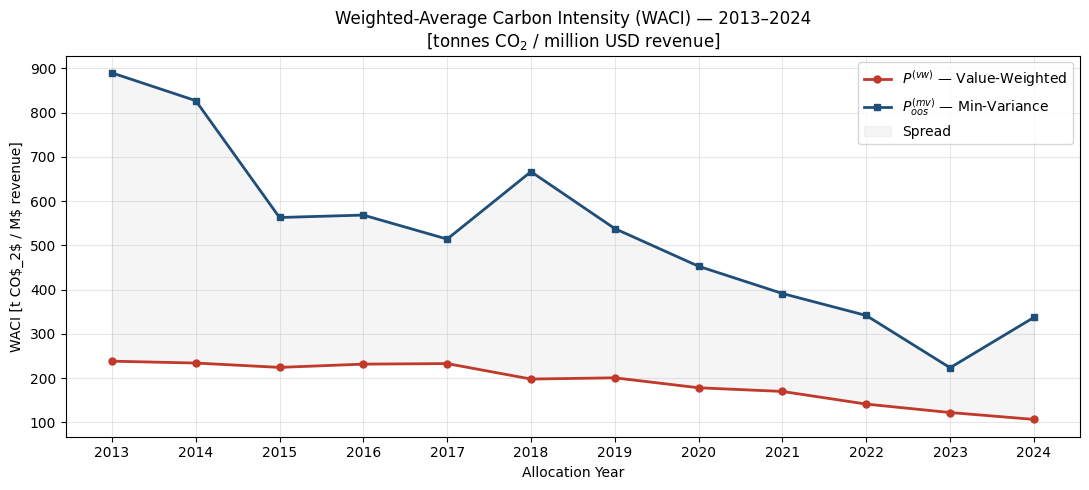

Avg WACI diff P(mv) vs P(vw): 172.7%  [82.7%, 273.2%]


In [8]:
years_plot   = list(range(Y0, Y_END + 1))
waci_mv_vals = [waci_mv[Y] for Y in years_plot]
waci_vw_vals = [waci_vw[Y] for Y in years_plot]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years_plot, waci_vw_vals, color=COLOR_VW, linewidth=2,
        marker='o', markersize=5, label=r'$P^{(vw)}$ — Value-Weighted')
ax.plot(years_plot, waci_mv_vals, color=COLOR_MV, linewidth=2,
        marker='s', markersize=5, label=r'$P^{(mv)}_{oos}$ — Min-Variance')
ax.fill_between(years_plot, waci_mv_vals, waci_vw_vals,
                alpha=0.08, color='grey', label='Spread')
ax.set_title('Weighted-Average Carbon Intensity (WACI) — 2013–2024\n'
             r'[tonnes CO$_2$ / million USD revenue]', fontsize=12)
ax.set_xlabel('Allocation Year')
ax.set_ylabel(r'WACI [t CO$_2$ / M$ revenue]')
ax.set_xticks(years_plot)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}waci_mv_vw.png', dpi=150, bbox_inches='tight')
plt.show()

waci_diff = [(waci_mv[Y] - waci_vw[Y]) / waci_vw[Y] * 100 for Y in years_plot]
print(f'Avg WACI diff P(mv) vs P(vw): {np.mean(waci_diff):.1f}%  '
      f'[{min(waci_diff):.1f}%, {max(waci_diff):.1f}%]')

### 6.2 CF

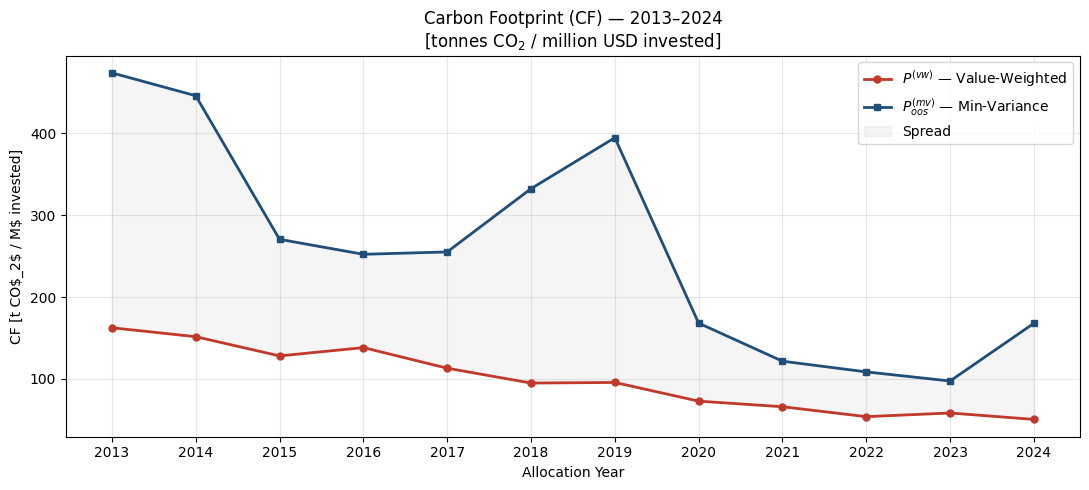

Avg CF diff P(mv) vs P(vw): 157.3%  [67.2%, 313.1%]


In [9]:
cf_mv_vals = [cf_mv[Y] for Y in years_plot]
cf_vw_vals = [cf_vw[Y] for Y in years_plot]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years_plot, cf_vw_vals, color=COLOR_VW, linewidth=2,
        marker='o', markersize=5, label=r'$P^{(vw)}$ — Value-Weighted')
ax.plot(years_plot, cf_mv_vals, color=COLOR_MV, linewidth=2,
        marker='s', markersize=5, label=r'$P^{(mv)}_{oos}$ — Min-Variance')
ax.fill_between(years_plot, cf_mv_vals, cf_vw_vals,
                alpha=0.08, color='grey', label='Spread')
ax.set_title('Carbon Footprint (CF) — 2013–2024\n'
             r'[tonnes CO$_2$ / million USD invested]', fontsize=12)
ax.set_xlabel('Allocation Year')
ax.set_ylabel(r'CF [t CO$_2$ / M$ invested]')
ax.set_xticks(years_plot)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}cf_mv_vw.png', dpi=150, bbox_inches='tight')
plt.show()

cf_diff = [(cf_mv[Y] - cf_vw[Y]) / cf_vw[Y] * 100 for Y in years_plot]
print(f'Avg CF diff P(mv) vs P(vw): {np.mean(cf_diff):.1f}%  '
      f'[{min(cf_diff):.1f}%, {max(cf_diff):.1f}%]')

### 6.3 Combined Panel

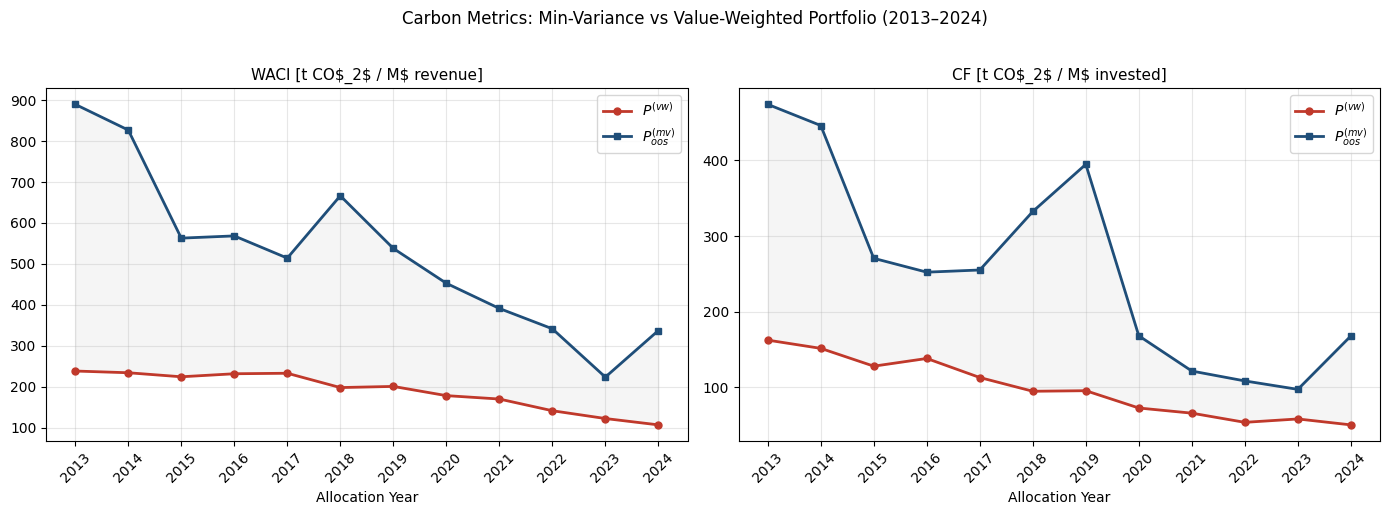

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(years_plot, waci_vw_vals, color=COLOR_VW, linewidth=2, marker='o', markersize=5, label=r'$P^{(vw)}$')
ax.plot(years_plot, waci_mv_vals, color=COLOR_MV, linewidth=2, marker='s', markersize=5, label=r'$P^{(mv)}_{oos}$')
ax.fill_between(years_plot, waci_mv_vals, waci_vw_vals, alpha=0.08, color='grey')
ax.set_title(r'WACI [t CO$_2$ / M$ revenue]', fontsize=11)
ax.set_xlabel('Allocation Year')
ax.set_xticks(years_plot)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(years_plot, cf_vw_vals, color=COLOR_VW, linewidth=2, marker='o', markersize=5, label=r'$P^{(vw)}$')
ax.plot(years_plot, cf_mv_vals, color=COLOR_MV, linewidth=2, marker='s', markersize=5, label=r'$P^{(mv)}_{oos}$')
ax.fill_between(years_plot, cf_mv_vals, cf_vw_vals, alpha=0.08, color='grey')
ax.set_title(r'CF [t CO$_2$ / M$ invested]', fontsize=11)
ax.set_xlabel('Allocation Year')
ax.set_xticks(years_plot)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('Carbon Metrics: Min-Variance vs Value-Weighted Portfolio (2013–2024)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}carbon_metrics_panel.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Top-10 Firms Driving Carbon Intensity Up

Two complementary rankings:

1. **Highest average CI** — intrinsic intensity, regardless of portfolio weight.
2. **Highest average WACI contribution** ($w_{i,Y} \times CI_{i,Y}$ in VW) — captures both
   intensity and market-cap weight, showing actual impact on portfolio-level WACI.

Vectorized `pd.concat` replaces the scalar `.get()` loop.

`n_years_in_set` = years the firm appears in any investment set;
`n_years_ci_valid` = years with non-NaN CI (the effective denominator of `CI_mean`).

In [11]:
# Vectorized construction: one DataFrame per year, then concat.
annual_frames = []
for Y in years_alloc:
    isins    = investment_sets[Y]
    Cap_all  = mv_y[Y].reindex(isins)
    cap_mask = Cap_all.notna() & (Cap_all > 0)
    cap_tot  = Cap_all[cap_mask].sum()

    w_vw_Y = pd.Series(0.0, index=isins)
    if cap_tot > 0:
        w_vw_Y[cap_mask] = Cap_all[cap_mask] / cap_tot

    CI_Y = CI[Y].reindex(isins)

    df_Y = pd.DataFrame({
        'ISIN' : isins,
        'Year' : Y,
        'CI'   : CI_Y.values,
        'w_vw' : w_vw_Y.values,
    })
    # WACI contribution: NaN when weight is zero or CI unavailable
    df_Y['WACI_contrib'] = np.where(
        (df_Y['w_vw'] > 0) & df_Y['CI'].notna(),
        df_Y['w_vw'] * df_Y['CI'], np.nan
    )
    annual_frames.append(df_Y)

df_firm_ci = pd.concat(annual_frames, ignore_index=True)

# Separate year counts: in-set vs CI-valid
df_firm_avg = (
    df_firm_ci
    .groupby('ISIN', sort=False)
    .agg(
        CI_mean           = ('CI',           'mean'),
        CI_max            = ('CI',           'max'),
        WACI_contrib_mean = ('WACI_contrib', 'mean'),
        n_years_in_set    = ('Year',         'count'),
        n_years_ci_valid  = ('CI',           lambda x: x.notna().sum()),
    )
    .reset_index()
)
df_firm_avg['Name'] = df_firm_avg['ISIN'].map(firm_names)

print(f'Unique ISINs tracked: {len(df_firm_avg)}')
print(f'With at least 1 valid CI: {(df_firm_avg["n_years_ci_valid"] > 0).sum()}')

Unique ISINs tracked: 586
With at least 1 valid CI: 586


In [12]:
# Table 1: Top 10 by average CI
top10_ci = (
    df_firm_avg[df_firm_avg['CI_mean'].notna()]
    .nlargest(10, 'CI_mean')
    [['ISIN', 'Name', 'CI_mean', 'CI_max', 'n_years_in_set', 'n_years_ci_valid']]
    .reset_index(drop=True)
)
top10_ci.index += 1

print('Top 10 by average Carbon Intensity (t CO2/M$ revenue), 2013-2024:')
print(f'{"Rank":<5}{"ISIN":<16}{"Firm Name":<40}{"Avg CI":>10}{"Max CI":>10}{"Yrs":>5}{"CI yrs":>8}')
print('-' * 96)
for rank, row in top10_ci.iterrows():
    print(f'{rank:<5}{row["ISIN"]:<16}{str(row["Name"])[:38]:<40}'
          f'{row["CI_mean"]:>10.1f}{row["CI_max"]:>10.1f}'
          f'{int(row["n_years_in_set"]):>5}{int(row["n_years_ci_valid"]):>8}')

Top 10 by average Carbon Intensity (t CO2/M$ revenue), 2013-2024:
Rank ISIN            Firm Name                                   Avg CI    Max CI  Yrs  CI yrs
------------------------------------------------------------------------------------------------
1    CA8239011031    SHERRITT INTL.RESTRCTD VTG                 20227.3   43452.1    9       9
2    CA89346D1078    TRANSALTA                                  11636.4   19066.4   12      12
3    US6708371033    OGE ENERGY                                  6354.7    9170.4   12      12
4    US0236081024    AMEREN                                      5003.8    6004.1   12      12
5    US0255371017    AMER.ELEC.PWR.                              4963.2    7989.8   12      12
6    US8425871071    SOUTHERN                                    4785.9    7316.9   12      12
7    US30034W1062    EVERGY                                      4648.9    5402.1    4       4
8    US92939U1060    WEC ENERGY GROUP                            4285.0    77

In [13]:
# Table 2: Top 10 by average WACI contribution in P(vw)
top10_waci = (
    df_firm_avg[df_firm_avg['WACI_contrib_mean'].notna()]
    .nlargest(10, 'WACI_contrib_mean')
    [['ISIN', 'Name', 'WACI_contrib_mean', 'CI_mean', 'n_years_in_set', 'n_years_ci_valid']]
    .reset_index(drop=True)
)
top10_waci.index += 1

print('Top 10 by average WACI contribution in P(vw) (w_{i,Y} x CI_{i,Y}), 2013-2024:')
print(f'{"Rank":<5}{"ISIN":<16}{"Firm Name":<40}{"Avg contrib":>12}{"Avg CI":>10}{"Yrs":>5}{"CI yrs":>8}')
print('-' * 98)
for rank, row in top10_waci.iterrows():
    print(f'{rank:<5}{row["ISIN"]:<16}{str(row["Name"])[:38]:<40}'
          f'{row["WACI_contrib_mean"]:>12.4f}{row["CI_mean"]:>10.1f}'
          f'{int(row["n_years_in_set"]):>5}{int(row["n_years_ci_valid"]):>8}')

Top 10 by average WACI contribution in P(vw) (w_{i,Y} x CI_{i,Y}), 2013-2024:
Rank ISIN            Firm Name                                Avg contrib    Avg CI  Yrs  CI yrs
--------------------------------------------------------------------------------------------------
1    US8425871071    SOUTHERN                                     13.9316    4785.9   12      12
2    US65339F1012    NEXTERA ENERGY                               10.7576    2651.9   12      12
3    US0255371017    AMER.ELEC.PWR.                                9.5256    4963.2   12      12
4    US26441C2044    DUKE ENERGY                                   7.9684    2998.7    6       6
5    US25746U1097    DOMINION ENERGY                               7.8584    2959.2   12      12
6    US30231G1022    EXXON MOBIL                                   7.5406     400.9   12      12
7    US0091581068    AIR PRDS.& CHEMS.                             5.3483    2712.5   12      12
8    US98389B1008    XCEL ENERGY               

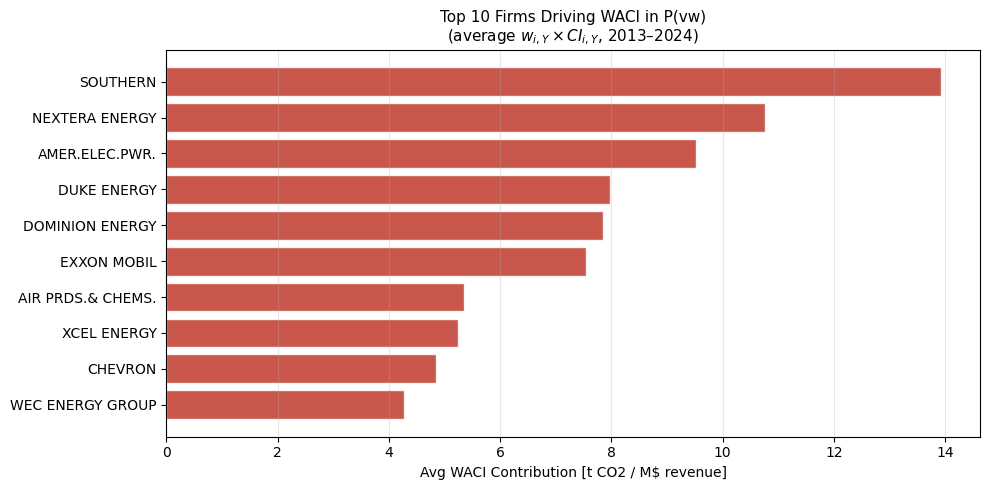

In [14]:
# Bar chart: Top 10 WACI contributors in P(vw)
short_names = top10_waci['Name'].apply(lambda x: str(x)[:25]).tolist()
contribs    = top10_waci['WACI_contrib_mean'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(short_names[::-1], contribs[::-1], color=COLOR_VW, alpha=0.85, edgecolor='white')
ax.set_xlabel('Avg WACI Contribution [t CO2 / M$ revenue]')
ax.set_title('Top 10 Firms Driving WACI in P(vw)\n'
             r'(average $w_{i,Y} \times CI_{i,Y}$, 2013–2024)', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}top10_waci_contributors.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Results

| File | Used in | Content |
|---|---|---|
| `ci_annual.csv` | 3.2, 3.3, 4.1 | $CI_{i,Y}$ for all firms and years |
| `cf_mv_annual.csv` | 3.2 | CF of $P^{(mv)}_{oos}$ per year |
| `cf_vw_annual.csv` | 3.3, 4.1 | CF of $P^{(vw)}$ per year |
| `waci_mv_annual.csv` | 3.4 | WACI of $P^{(mv)}_{oos}$ per year |
| `waci_vw_annual.csv` | 3.4 | WACI of $P^{(vw)}$ per year |
| `cf_vw_baseline.txt` | 4.1 | $CF^{(vw)}_{Y_0=2013}$ (net-zero reference) |

**Reload pattern for downstream notebooks:**
```python
cf_mv = pd.read_csv(f'{DATA_DIR}cf_mv_annual.csv', index_col=0)['CF_mv']
cf_mv.index = cf_mv.index.astype(int)   # restore integer year keys
cf_mv = cf_mv.to_dict()

with open(f'{DATA_DIR}cf_vw_baseline.txt') as fh:
    cf_vw_baseline = float(fh.read())
```

In [15]:
CI.to_csv(f'{DATA_DIR}ci_annual.csv')

pd.Series(cf_mv,   name='CF_mv').rename_axis('Year').to_csv(
    f'{DATA_DIR}cf_mv_annual.csv', header=True)
pd.Series(cf_vw,   name='CF_vw').rename_axis('Year').to_csv(
    f'{DATA_DIR}cf_vw_annual.csv', header=True)
pd.Series(waci_mv, name='WACI_mv').rename_axis('Year').to_csv(
    f'{DATA_DIR}waci_mv_annual.csv', header=True)
pd.Series(waci_vw, name='WACI_vw').rename_axis('Year').to_csv(
    f'{DATA_DIR}waci_vw_annual.csv', header=True)

# repr() guarantees a lossless float roundtrip on all platforms
with open(f'{DATA_DIR}cf_vw_baseline.txt', 'w') as fh:
    fh.write(repr(float(cf_vw_baseline)))   # convert to Python float first

print('Saved to cleaned_data/:')
for f in ['ci_annual.csv', 'cf_mv_annual.csv', 'cf_vw_annual.csv',
          'waci_mv_annual.csv', 'waci_vw_annual.csv', 'cf_vw_baseline.txt']:
    kb = os.path.getsize(f'{DATA_DIR}{f}') / 1024
    print(f'  {f:<35} {kb:>8.1f} KB')

print(f'\nCharts saved to {CHARTS_DIR}:')
for f in ['waci_mv_vw.png','cf_mv_vw.png','carbon_metrics_panel.png',
          'top10_waci_contributors.png']:
    if os.path.exists(f'{CHARTS_DIR}{f}'):
        print(f'  {f}')

print('\nNext step: Section 3.2 — Long-only portfolio with 50% CF reduction constraint.')

Saved to cleaned_data/:
  ci_annual.csv                          157.7 KB
  cf_mv_annual.csv                         0.3 KB
  cf_vw_annual.csv                         0.3 KB
  waci_mv_annual.csv                       0.3 KB
  waci_vw_annual.csv                       0.3 KB
  cf_vw_baseline.txt                       0.0 KB

Charts saved to ./Charts/:
  waci_mv_vw.png
  cf_mv_vw.png
  carbon_metrics_panel.png
  top10_waci_contributors.png

Next step: Section 3.2 — Long-only portfolio with 50% CF reduction constraint.


## Summary

In [16]:
print('SECTION 3.1 — SUMMARY')
print('=' * 58)
print(f'Region / Scope : AMER / Scope 1+2')
print(f'Sample         : {Y0}-{Y_END}  ({Y_END - Y0 + 1} allocation years)')
print()
print(f'{"Year":<6} {"WACI(mv)":>10} {"WACI(vw)":>10} {"CF(mv)":>10} {"CF(vw)":>10}')
print('-' * 50)
for Y in years_alloc:
    print(f'{Y:<6} {waci_mv[Y]:>10.2f} {waci_vw[Y]:>10.2f} '
          f'{cf_mv[Y]:>10.4f} {cf_vw[Y]:>10.4f}')
print('-' * 50)
print(f'{"Mean":<6} '
      f'{np.mean(list(waci_mv.values())):>10.2f} '
      f'{np.mean(list(waci_vw.values())):>10.2f} '
      f'{np.mean(list(cf_mv.values())):>10.4f} '
      f'{np.mean(list(cf_vw.values())):>10.4f}')
print()
print(f'Net-zero baseline CF(vw) at Y0={Y0}: {cf_vw_baseline:.6f} t/M$')
print('=' * 58)

SECTION 3.1 — SUMMARY
Region / Scope : AMER / Scope 1+2
Sample         : 2013-2024  (12 allocation years)

Year     WACI(mv)   WACI(vw)     CF(mv)     CF(vw)
--------------------------------------------------
2013       889.68     238.36   474.0099   162.3932
2014       826.93     234.16   446.0416   151.5021
2015       562.96     224.32   270.5141   127.9810
2016       568.40     231.70   252.2170   138.1504
2017       514.15     232.92   255.1046   112.9706
2018       666.44     197.98   332.4095    94.8164
2019       537.87     200.77   394.7436    95.5531
2020       452.73     178.28   168.0937    72.6892
2021       391.22     169.98   121.5414    65.8731
2022       341.57     141.40   108.4703    53.7419
2023       223.52     122.36    97.3207    58.2167
2024       337.26     106.85   167.8866    50.3890
--------------------------------------------------
Mean       526.06     189.92   257.3628    98.6897

Net-zero baseline CF(vw) at Y0=2013: 162.393180 t/M$
